In [1]:
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(dplyr)
  library(NMF)
  library(pdacR)
  library(singscore)
})


Warning message:
“replacing previous import ‘Seurat::Assays’ by ‘SummarizedExperiment::Assays’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘ggpubr::mutate’ by ‘plyr::mutate’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘Biobase::exprs’ by ‘rlang::exprs’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘readr::col_factor’ by ‘scales::col_factor’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘shiny::runExample’ by ‘shinyjs::runExample’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘limma::show’ by ‘shinyjs::show’ when loading ‘pdacR’”


In [2]:
#pdacR::gene_lists

## Loading data

In [3]:
met_high_df <- read.csv("/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/met-high-genes-human.csv")
met_low_df  <- read.csv("/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/met-low-genes-human.csv")
met_high_genes <- na.omit(met_high_df$SYMBOL)
met_low_genes  <- na.omit(met_low_df$SYMBOL)

file_path <- system.file("data", "TCGA_PAAD.rds", package = "pdacR")
TCGA_PAAD <- readRDS(file_path)

In [4]:
TCGA_PAAD

TCGA-2L-AAQE-01A,TCGA-XD-AAUL-01A,TCGA-3A-A9IN-01A,TCGA-3A-A9IS-01A,TCGA-2L-AAQJ-01A,TCGA-2L-AAQI-01A,TCGA-3A-A9IB-01A,TCGA-3A-A9IU-01A,TCGA-2L-AAQM-01A,TCGA-FB-AAPS-01A,⋯,TCGA-3E-AAAZ-01A,TCGA-F2-A7TX-01A,TCGA-IB-AAUN-01A,TCGA-IB-AAUV-01A,TCGA-IB-AAUW-01A,TCGA-IB-AAUO-01A,TCGA-3A-A9IL-01A,TCGA-3A-A9IC-01A,TCGA-IB-AAUR-01A,TCGA-FB-A545-01A
45872.5672,37171.3098,31579.6767,48688.7778,37995.5446,27483.1895,43594.4775,40796.5729,57633.2344,37262.0690,⋯,33551.9820,38980.2726,44311.9730,38740.7867,35234.3689,46426.7620,26059.0162,47613.3333,30059.0622,47703.2551
0.4634,3.7422,4.0416,0.0000,1.9802,4.3727,0.8062,2.1968,0.5935,30.3448,⋯,1.4959,0.8795,3.3727,8.2816,0.7865,2.4594,0.0000,10.8642,5.4103,0.7570
46.8026,1733.4719,4.6189,3.1804,40.0990,18923.4492,38098.9620,53504.8330,10.6825,13213.7931,⋯,20953.2536,112601.1434,225491.8494,748.6542,61323.2403,742.2419,384.4509,123.4568,0.9017,669.1900
419.3698,387.1102,810.0462,363.0168,358.9109,452.3282,526.8568,492.5308,248.6647,750.3448,⋯,487.6589,376.4292,344.5756,866.6667,655.9182,227.2470,535.6576,526.4198,698.8278,449.6593
416.5894,520.9979,755.1963,848.7051,330.6931,395.9694,364.0028,326.8893,1430.8605,764.8276,⋯,610.6956,371.1522,355.2558,706.8323,549.7444,462.8559,1157.6423,785.1852,659.1524,352.0061
614.9212,457.3805,434.1801,469.3321,440.5941,489.7388,403.9101,381.3708,618.3976,417.9310,⋯,458.1152,429.6394,449.1287,356.9358,489.5792,500.7304,331.9039,441.4815,253.8323,678.2740
2.3170,0.0000,2.3095,5.9064,1.4851,0.4859,0.0000,0.4394,4.1543,2.0690,⋯,0.0000,1.7590,0.0000,2.4845,1.5729,2.4594,8.0429,0.9877,2.7051,0.0000
41.7053,134.7193,136.2587,304.4071,40.0990,34.4955,120.5281,66.3445,185.7567,30.3448,⋯,21.6904,34.3008,19.6740,24.8447,37.7507,62.4683,143.6999,34.0741,29.3057,27.2521
309.0825,532.6403,935.9122,1786.4607,505.4455,803.5992,975.9145,639.2794,1078.9318,739.3103,⋯,606.5819,506.1566,734.6824,983.4369,641.3685,276.4347,1069.7065,650.3704,677.1867,663.8910
1139.4810,596.2578,338.3372,123.1259,688.6139,467.8755,411.5691,277.6801,95.5490,522.7586,⋯,229.2446,446.7898,797.6391,274.9482,286.6693,339.3949,200.0003,684.9383,353.4716,261.1658


## Preparing MetScore Label

In [7]:
# PREPARE THE EXPRESSION MATRIX
expression_matrix <- as.matrix(TCGA_PAAD$ex)

rownames(expression_matrix) <- TCGA_PAAD$featInfo$SYMBOL

tcga_paad_ranked <- rankGenes(expression_matrix)

In [8]:
# Calculate the MetScore using simpleScore
met_scores <- simpleScore(tcga_paad_ranked, upSet = met_high_genes, downSet = met_low_genes)

Warning message in checkGenes(upSet, rownames(rankData)):
“14 genes missing: SPMIP3, CAVIN2, NABP1, CFAP69, CRACR2A, TENT5B, ACKR3, TMEM238L, JADE3, SEPTIN8, TMPRSS11E, SOWAHB, NHSL3, ARHGAP40”
Warning message in checkGenes(downSet, rownames(rankData)):
“14 genes missing: ENTREP1, NREP, PIEZO2, CCN3, CPED1, ADGRF5, AOPEP, GPR15LG, MALRD1, CLDN34, DENND11, ARHGAP44, KNOP1, FAM222B”


In [27]:
met_scores

,TotalScore,TotalDispersion,UpScore,UpDispersion,DownScore,DownDispersion
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TCGA-2L-AAQE-01A,0.063381682,5421.127,0.16218083,5195.030,-0.09879915,5647.223
TCGA-XD-AAUL-01A,0.075325965,5289.546,0.17065204,4851.067,-0.09532608,5728.025
TCGA-3A-A9IN-01A,0.004815070,5910.014,0.12082650,6169.099,-0.11601143,5650.930
TCGA-3A-A9IS-01A,-0.009044271,5904.454,0.08622627,5279.539,-0.09527054,6529.370
TCGA-2L-AAQJ-01A,0.085065625,5594.591,0.18291827,5223.200,-0.09785265,5965.982
TCGA-2L-AAQI-01A,0.070770457,5408.525,0.18353247,5157.224,-0.11276201,5659.825
TCGA-3A-A9IB-01A,0.052545154,5402.224,0.16263763,5433.729,-0.11009247,5370.718
TCGA-3A-A9IU-01A,0.087381247,5412.602,0.17331959,5405.560,-0.08593834,5419.644
TCGA-2L-AAQM-01A,0.021545992,5949.303,0.12197829,5824.394,-0.10043229,6074.212


In [9]:
TCGA_PAAD$sampInfo$MetScore <- met_scores$TotalScore

## Preparing TCGA

In [10]:
## Preparation of TCGA data
#RSEM counts can be rounded to the nearest integer
## RSEM assigns reads with multiple mappings -- they are counts, but a fractional amount can be assigned to a gene.
TCGA_PAAD$ex <- round(TCGA_PAAD$ex)


#remove expression of unhelpful "?" genes
#this gives the index of rows that are "?"
feat_q <- which(TCGA_PAAD$featInfo == "?")
## TCGA_PAAD is organized so that the rows of ex are in the same order as featInfo (feature info)
## and the columns of ex are in the same order as sampInfo (sample info)
# To maintain this order, removals need to be done to both 
TCGA_PAAD$ex <- TCGA_PAAD$ex[-feat_q,]
TCGA_PAAD$featInfo <- TCGA_PAAD$featInfo[-feat_q,]


#------------------

## "whitelist" filter determined by original TCGA paper
# remove the samples that are not part of the whitelist
wl_filter <- TCGA_PAAD$sampInfo$Filter_by == "whitelist"
TCGA_PAAD$sampInfo <- TCGA_PAAD$sampInfo[wl_filter,]
TCGA_PAAD$ex <- TCGA_PAAD$ex[,wl_filter]

#------------------


# remove TCGA-US-A776 (outlier, precursor tumor)
# This sample is part of the whitelist, but is not PDAC
USA776 <- which(TCGA_PAAD$sampInfo$Tumor.Sample.ID == "TCGA-US-A776-01A")
TCGA_PAAD$sampInfo <- TCGA_PAAD$sampInfo[-USA776,]
TCGA_PAAD$ex <- TCGA_PAAD$ex[,-USA776]

#------------------

## Some genes have 0 expression across all samples and can be removed
remove0 <- which(rowSums(TCGA_PAAD$ex) == 0)
TCGA_PAAD$ex <- TCGA_PAAD$ex[-remove0,]
TCGA_PAAD$featInfo <- TCGA_PAAD$featInfo[-remove0,]


## Check that they still have the same number of genes
dim(TCGA_PAAD$ex)

[1] 19840   149

In [11]:
dim(TCGA_PAAD$featInfo)

[1] 19840     2

## Preparing genelist (substituted with Jesse's met-high and met-low genelist)

In [12]:
sub_genelist <- data.frame(SYMBOL=gene_lists$Moffitt.F12_Endocrine.top250, class="Endocrine") %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F3_Exocrine.top250, class="Exocrine")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F5_ActivatedStroma.top250, class="Activated Stroma")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F13_NormalStroma.top250, class="Normal Stroma")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F7_Immune.top250, class="Immune")) %>%
  rbind(data.frame(SYMBOL=met_high_genes_clean, class="MetHigh")) %>%    
  rbind(data.frame(SYMBOL=met_low_genes_clean, class="MetLow"))       

In [13]:
rownames(sub_genelist) <- sub_genelist$SYMBOL

ex_sub <- TCGA_PAAD$ex[TCGA_PAAD$featInfo$SYMBOL %in% sub_genelist$SYMBOL, ]
featInfo_sub <- TCGA_PAAD$featInfo[TCGA_PAAD$featInfo$SYMBOL %in% sub_genelist$SYMBOL, ]


dim(ex_sub)
dim(featInfo_sub)

[1] 1458  149

[1] 1458    2

### Checking Overlaps

In [ ]:
group_lists <- list(
  "Endocrine" = gene_lists$Moffitt.F12_Endocrine.top250,
  "Exocrine" = gene_lists$Moffitt.F3_Exocrine.top250,
  "Activated Stroma" = gene_lists$Moffitt.F5_ActivatedStroma.top250,
  "Normal Stroma" = gene_lists$Moffitt.F13_NormalStroma.top250,
  "Immune" = gene_lists$Moffitt.F7_Immune.top250,
  "MetHigh" = met_high_genes,  
  "MetLow" = met_low_genes
)


all_genes <- unlist(group_lists)

gene_counts <- table(all_genes)

overlapping_genes <- names(gene_counts[gene_counts > 1])


overlap_locations <- sapply(overlapping_genes, function(gene) {

  found_in_groups <- names(group_lists)[sapply(group_lists, function(g) gene %in% g)]
  
  paste(found_in_groups, collapse = " + ")
})


overlap_details_df <- data.frame(
  Gene = overlapping_genes,
  Belongs_To_Groups = overlap_locations,
  row.names = NULL
)


#print(overlap_details_df)

In [ ]:
overlap_details_df$Belongs_To_Groups <- as.factor(overlap_details_df$Belongs_To_Groups)


overlap_frequencies <- summary(overlap_details_df$Belongs_To_Groups)
print(overlap_frequencies)

### Deleting genes

In [ ]:
met_high_genes_clean <- setdiff(met_high_genes, overlapping_genes)
met_low_genes_clean <- setdiff(met_low_genes, overlapping_genes)


print(paste("[MetHigh] Original Count:", length(met_high_genes), 
            "-> Cleaned Count:", length(met_high_genes_clean)))

print(paste("[MetLow] Original Count:", length(met_low_genes), 
            "-> Cleaned Count:", length(met_low_genes_clean)))

## Setting up NMF

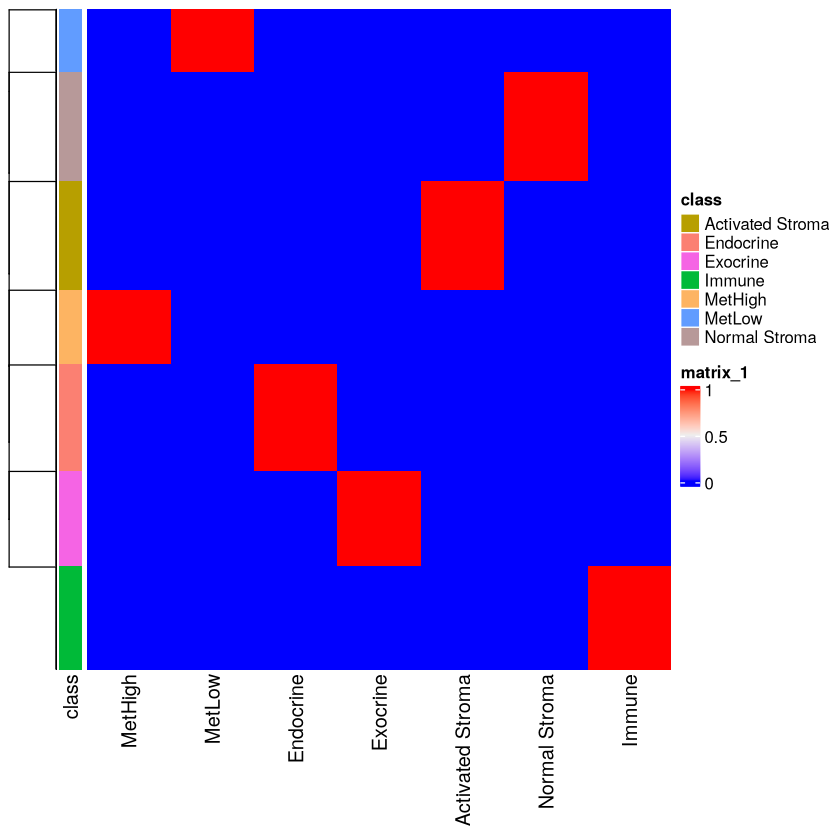

In [14]:
k <- 7
RNA_val <- 1
default_RNA <- 0.01


W.seed.rna <- matrix(default_RNA, nrow=nrow(ex_sub), ncol=k)


W.seed.rna[which(featInfo_sub$SYMBOL %in% met_high_genes_clean), 1] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% met_low_genes_clean), 2] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% gene_lists$Moffitt.F12_Endocrine.top250), 3] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% gene_lists$Moffitt.F3_Exocrine.top250), 4] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% gene_lists$Moffitt.F5_ActivatedStroma.top250), 5] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% gene_lists$Moffitt.F13_NormalStroma.top250), 6] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% gene_lists$Moffitt.F7_Immune.top250), 7] <- RNA_val



colnames(W.seed.rna) <- c("MetHigh", "MetLow", "Endocrine", "Exocrine",
                          "Activated Stroma", "Normal Stroma", "Immune"
                          )


Heatmap(W.seed.rna, cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          df = sub_genelist[featInfo_sub$SYMBOL, "class", drop = FALSE],
          col = list(
            class = c("MetHigh" = "#fdb462", "MetLow" = "#619cff", 
                      "Endocrine" = "#fb8072", "Exocrine" = "#f564e4", 
                      "Activated Stroma" = "#b79f00", "Normal Stroma" = "#b79999", 
                      "Immune" = "#00ba38")
          )
        )
)



In [15]:
H.seed.rna <- matrix(0.05, nrow=k, ncol=ncol(ex_sub))

H.seed.rna <- nmf_update.euclidean.h(ex_sub, W.seed.rna, H.seed.rna)


In [16]:
RNA_seed <- NMF::nmfModel(W = W.seed.rna, H = H.seed.rna)

RNA_solved <- NMF::nmf(ex_sub, seed=RNA_seed, .opt=list(parallel=TRUE, verbose=FALSE))

## Solution to W matrix for RNA

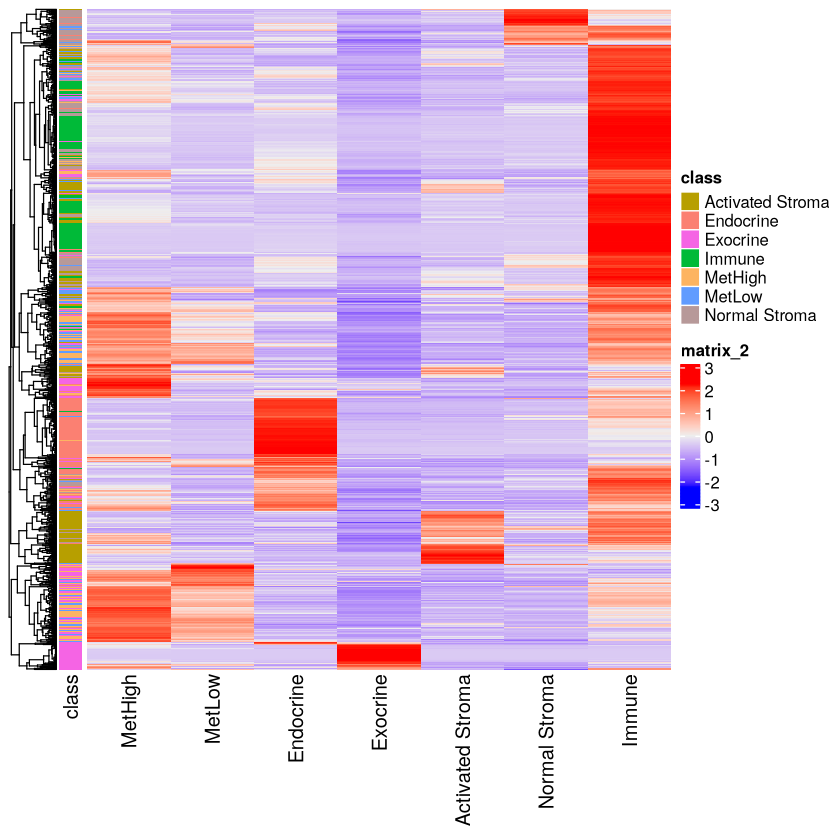

In [17]:
RNA_W <- RNA_solved@fit@W

Heatmap(t(scale(t(RNA_W))), cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          
          df = sub_genelist[featInfo_sub$SYMBOL, "class", drop = FALSE],
          col = list(
            
            class = c("MetHigh" = "#fdb462", "MetLow" = "#619cff", 
                      "Endocrine" = "#fb8072", "Exocrine" = "#f564e4", 
                      "Activated Stroma" = "#b79f00", "Normal Stroma" = "#b79999", 
                      "Immune" = "#00ba38")
          )
        )
)

## Solution to H matrix for RNA

The automatically generated colors map from the 1^st and 99^th of the
values in the matrix. There are outliers in the matrix whose patterns
might be hidden by this color mapping. You can manually set the color
to `col` argument.

Use `suppressMessages()` to turn off this message.



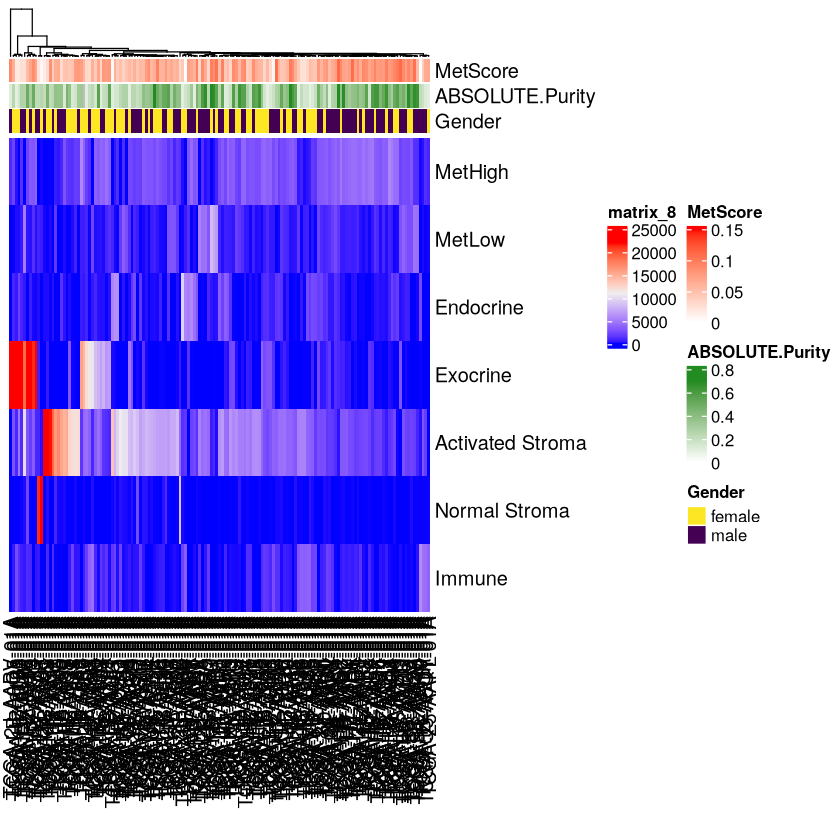

In [25]:
RNA_H <- RNA_solved@fit@H

colnames(RNA_H) <- TCGA_PAAD$sampInfo$Tumor.Sample.ID


rownames(RNA_H) <- c("MetHigh", "MetLow", "Endocrine", "Exocrine",
                     "Activated Stroma", "Normal Stroma", "Immune"
                     )

Heatmap(RNA_H, cluster_columns = TRUE, cluster_rows = FALSE,
        
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("MetScore", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            MetScore = colorRamp2(c(0, 0.15), c("white", "red")),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)

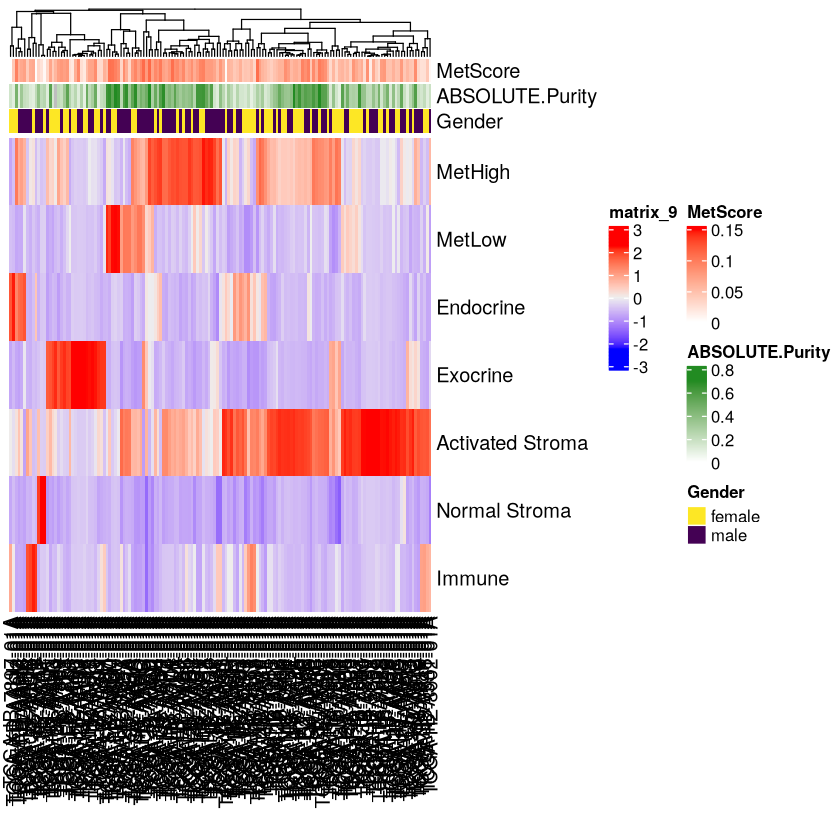

In [26]:
Heatmap(scale(RNA_H), cluster_columns = TRUE, cluster_rows = FALSE,
        
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("MetScore", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            MetScore = colorRamp2(c(0, 0.15), c("white", "red")),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)

In [22]:
TCGA_PAAD$sampInfo$MetScore

[1]  0.063381682  0.075325965  0.085065625  0.070770457  0.052545154
  [6]  0.087381247  0.027873025  0.093179228  0.061855130  0.075652310
 [11]  0.090541894  0.059984917  0.047374015  0.054893507  0.090174350
 [16]  0.076421918  0.057096578  0.032303258  0.054336957  0.077294383
 [21]  0.059837522  0.005997858  0.089458503  0.047234733  0.089799819
 [26]  0.057548531  0.076944029  0.096093536  0.077656028  0.064266806
 [31]  0.072266677  0.004112634  0.081413753  0.098632297  0.073052648
 [36]  0.042002318  0.029181615  0.072764578  0.095472304  0.106352706
 [41]  0.073104103  0.045819016  0.083470594  0.045685932  0.067294455
 [46]  0.095398897  0.063900575  0.038459035  0.043906449  0.069628650
 [51]  0.075539209  0.056191739  0.055538910  0.066150230  0.074458227
 [56]  0.078915151  0.059551613  0.014585305  0.056730373  0.061057671
 [61]  0.032253043 -0.005446130  0.032344090  0.006097950  0.042808411
 [66]  0.017312473  0.032350882  0.024571029  0.027958005  0.030378319
 [71]  0.062572736  0.037512188  0.053221008  0.002388175  0.058791836
 [76]  0.043638402  0.047085912  0.017682770  0.024101563  0.029581027
 [81]  0.045866503  0.042167911  0.088532059  0.052419471  0.057369849
 [86]  0.060887892  0.056246837  0.040086541  0.058181274  0.063118110
 [91]  0.074618462  0.084851027  0.080173621  0.065247375  0.094297796
 [96]  0.078741986  0.108006864  0.055087771  0.090778056  0.099779458
[101]  0.111789031  0.040927709  0.110330336  0.054365049  0.064395578
[106]  0.042009786  0.054556360  0.048111844  0.076329041  0.107692633
[111]  0.069676003  0.022723002  0.087102875  0.095792932  0.036286598
[116]  0.067295366  0.085266586  0.048809362  0.078605216  0.053342335
[121]  0.073583258  0.060826277  0.104848149  0.043706030  0.031809575
[126]  0.084951571  0.092332096  0.086784734  0.026003168  0.023449472
[131]  0.032447428  0.084165226  0.073438628  0.046984323  0.077891675
[136]  0.052088731  0.086541695  0.078901309  0.067142506  0.069888746
[141]  0.043550375  0.051780744  0.031090794  0.078649600  0.068906129
[146]  0.089493495  0.063881574  0.040454022  0.063933567

# With other classification

### Checking duplicate in the Met genes and delete them from the list

In [ ]:
group_lists <- list(
  "Basal-like" = gene_lists$Moffitt.F6_BasalLike.top250,
  "Classical" = gene_lists$Moffitt.F8_Classical.top250,
  "Endocrine" = gene_lists$Moffitt.F12_Endocrine.top250,
  "Exocrine" = gene_lists$Moffitt.F3_Exocrine.top250,
  "Activated Stroma" = gene_lists$Moffitt.F5_ActivatedStroma.top250,
  "Normal Stroma" = gene_lists$Moffitt.F13_NormalStroma.top250,
  "Immune" = gene_lists$Moffitt.F7_Immune.top250,
  "MetHigh" = met_high_genes,  
  "MetLow" = met_low_genes
)


all_genes <- unlist(group_lists)

gene_counts <- table(all_genes)

overlapping_genes <- names(gene_counts[gene_counts > 1])


overlap_locations <- sapply(overlapping_genes, function(gene) {

  found_in_groups <- names(group_lists)[sapply(group_lists, function(g) gene %in% g)]
  
  paste(found_in_groups, collapse = " + ")
})


overlap_details_df <- data.frame(
  Gene = overlapping_genes,
  Belongs_To_Groups = overlap_locations,
  row.names = NULL
)


#print(overlap_details_df)

In [ ]:
overlap_details_df$Belongs_To_Groups <- as.factor(overlap_details_df$Belongs_To_Groups)


overlap_frequencies <- summary(overlap_details_df$Belongs_To_Groups)
print(overlap_frequencies)

In [ ]:
met_high_genes_clean <- setdiff(met_high_genes, overlapping_genes)
met_low_genes_clean <- setdiff(met_low_genes, overlapping_genes)


print(paste("[MetHigh] Original Count:", length(met_high_genes), 
            "-> Cleaned Count:", length(met_high_genes_clean)))

print(paste("[MetLow] Original Count:", length(met_low_genes), 
            "-> Cleaned Count:", length(met_low_genes_clean)))

In [28]:
combined_genelist <- data.frame(SYMBOL=gene_lists$Moffitt.F6_BasalLike.top250, class="Basal-like") %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F8_Classical.top250, class="Classical")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F12_Endocrine.top250, class="Endocrine")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F3_Exocrine.top250, class="Exocrine")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F5_ActivatedStroma.top250, class="Activated Stroma")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F13_NormalStroma.top250, class="Normal Stroma")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F7_Immune.top250, class="Immune")) %>%
  rbind(data.frame(SYMBOL=met_high_genes_clean, class="MetHigh")) %>%    
  rbind(data.frame(SYMBOL=met_low_genes_clean, class="MetLow"))          

In [29]:
rownames(combined_genelist) <- combined_genelist$SYMBOL

ex_combined <- TCGA_PAAD$ex[TCGA_PAAD$featInfo$SYMBOL %in% combined_genelist$SYMBOL, ]
featInfo_combined <- TCGA_PAAD$featInfo[TCGA_PAAD$featInfo$SYMBOL %in% combined_genelist$SYMBOL, ]


dim(ex_combined)
dim(featInfo_combined)

[1] 1925  149

[1] 1925    2

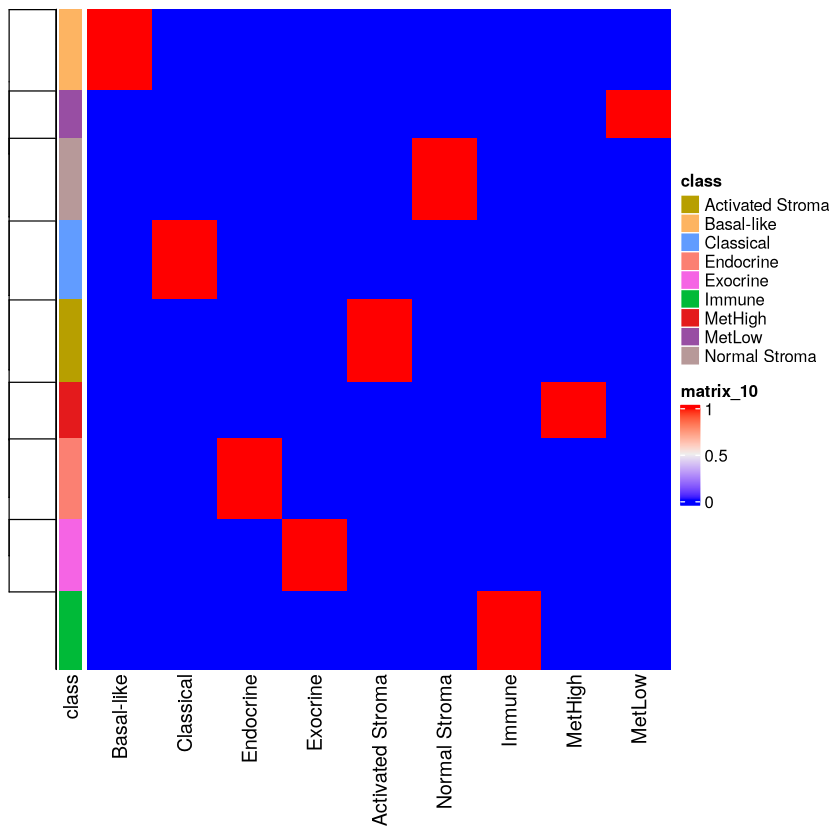

In [30]:
k <- 9
RNA_val <- 1
default_RNA <- 0.01


W.seed.rna <- matrix(default_RNA, nrow=nrow(ex_combined), ncol=k)


W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F6_BasalLike.top250), 1] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F8_Classical.top250), 2] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F12_Endocrine.top250), 3] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F3_Exocrine.top250), 4] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F5_ActivatedStroma.top250), 5] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F13_NormalStroma.top250), 6] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F7_Immune.top250), 7] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% met_high_genes_clean), 8] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% met_low_genes_clean), 9] <- RNA_val


colnames(W.seed.rna) <- c("Basal-like", "Classical", "Endocrine", "Exocrine",
                          "Activated Stroma", "Normal Stroma", "Immune",
                          "MetHigh", "MetLow")


Heatmap(W.seed.rna, cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          df = combined_genelist[featInfo_combined$SYMBOL, "class", drop = FALSE],
          col = list(
            class = c("Basal-like" = "#fdb462", "Classical" = "#619cff", 
                      "Endocrine" = "#fb8072", "Exocrine" = "#f564e4", 
                      "Activated Stroma" = "#b79f00", "Normal Stroma" = "#b79999", 
                      "Immune" = "#00ba38", "MetHigh" = "#E41A1C", "MetLow" = "#984EA3")
          )
        )
)



In [31]:
H.seed.rna <- matrix(0.05, nrow=k, ncol=ncol(ex_combined))

H.seed.rna <- nmf_update.euclidean.h(ex_combined, W.seed.rna, H.seed.rna)

In [32]:
RNA_seed <- NMF::nmfModel(W = W.seed.rna, H = H.seed.rna)

RNA_solved <- NMF::nmf(ex_combined, seed=RNA_seed, .opt=list(parallel=TRUE, verbose=FALSE))

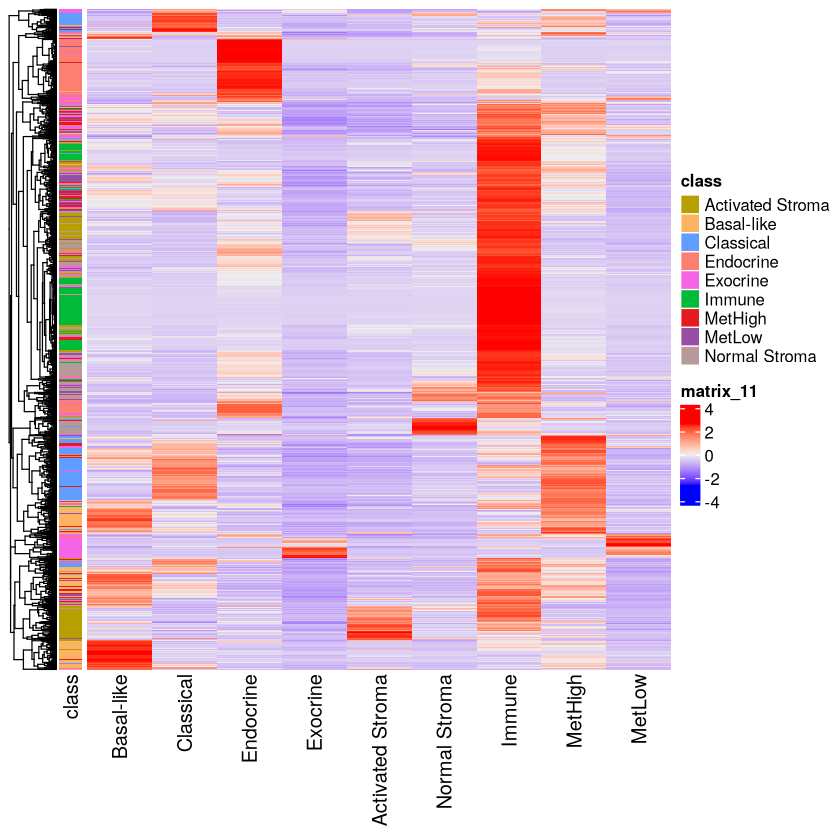

In [33]:
RNA_W <- RNA_solved@fit@W

Heatmap(t(scale(t(RNA_W))), cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          
          df = combined_genelist[featInfo_combined$SYMBOL, "class", drop = FALSE],
          col = list(
            
            class = c("Basal-like" = "#fdb462", "Classical" = "#619cff", 
                      "Endocrine" = "#fb8072", "Exocrine" = "#f564e4", 
                      "Activated Stroma" = "#b79f00", "Normal Stroma" = "#b79999", 
                      "Immune" = "#00ba38", "MetHigh" = "#E41A1C", "MetLow" = "#984EA3")
          )
        )
)

The automatically generated colors map from the 1^st and 99^th of the
values in the matrix. There are outliers in the matrix whose patterns
might be hidden by this color mapping. You can manually set the color
to `col` argument.

Use `suppressMessages()` to turn off this message.



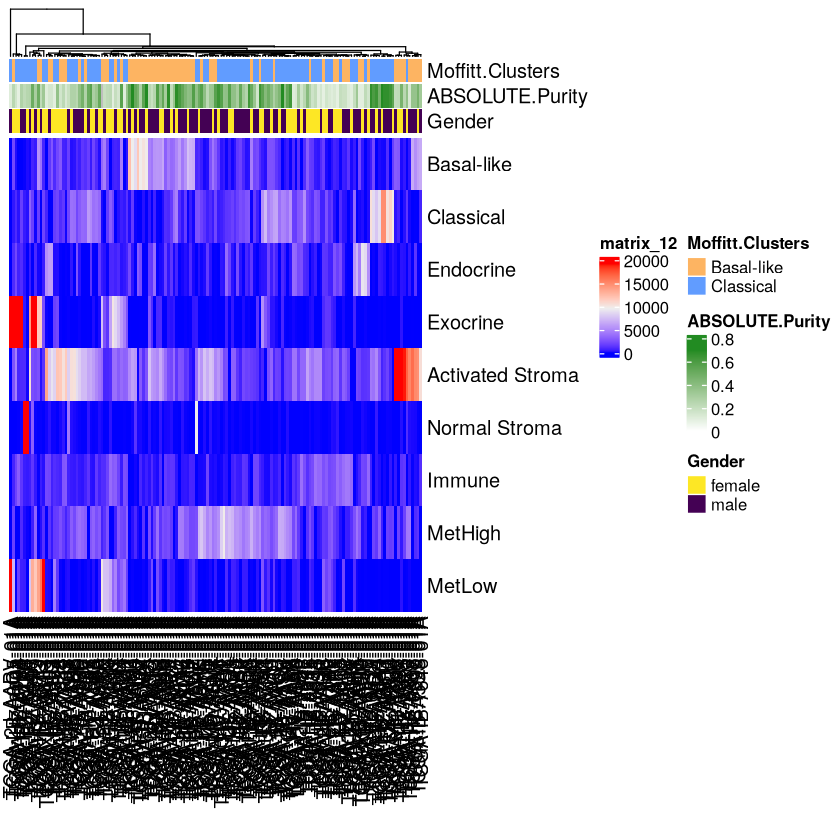

In [34]:
RNA_H <- RNA_solved@fit@H

colnames(RNA_H) <- TCGA_PAAD$sampInfo$Tumor.Sample.ID


rownames(RNA_H) <- c("Basal-like", "Classical", "Endocrine", "Exocrine",
                     "Activated Stroma", "Normal Stroma", "Immune",
                     "MetHigh", "MetLow")

Heatmap(RNA_H, cluster_columns = TRUE, cluster_rows = FALSE,
        
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("Moffitt.Clusters", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            Moffitt.Clusters = c("Basal-like" = "#fdb462", "Classical" = "#619cff"),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)

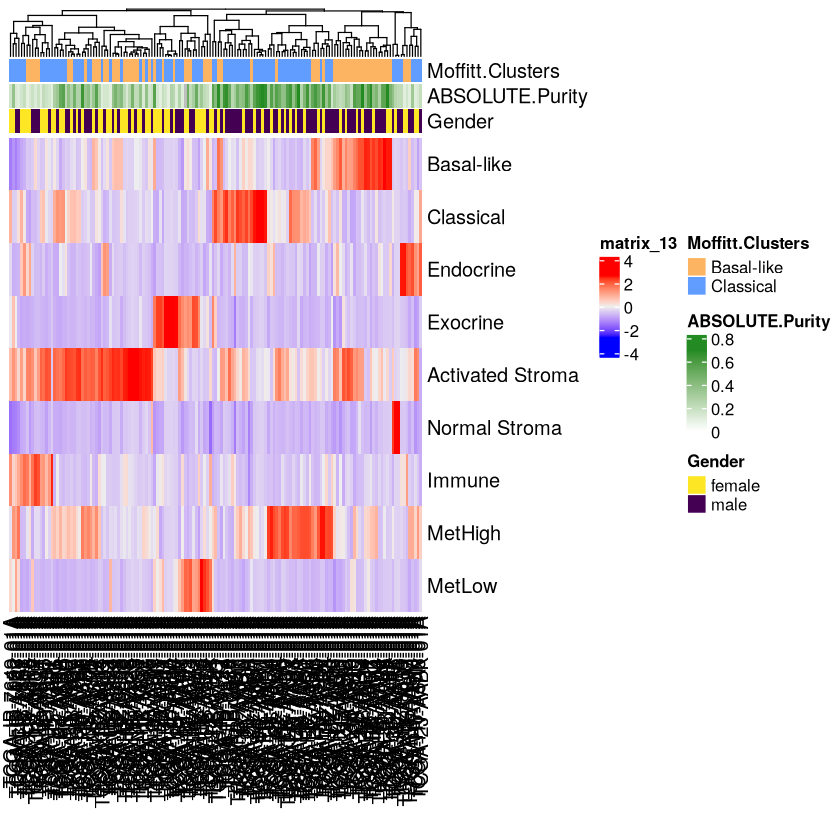

In [35]:
Heatmap(scale(RNA_H), cluster_columns = TRUE, cluster_rows = FALSE,
        
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("Moffitt.Clusters", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            Moffitt.Clusters = c("Basal-like" = "#fdb462", "Classical" = "#619cff"),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)

# THE BIG NMF